In [1]:
import os, torch, glob
import numpy as np
from PIL import Image
from torchvision import transforms
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# Configuration
DATA_ROOT = "/Users/user/X-Ray Project/Data"
IMAGE_DIR = os.path.join(DATA_ROOT, "Roboflow_1569/test")
ANN_FILE  = os.path.join(DATA_ROOT, "Roboflow_1569/test/_annotations.coco.json")
INHOUSE   = os.path.join(DATA_ROOT, "RAXO_WEB_InHouse")
CLASSES   = ["Gun", "Scissors", "Knife"]

device = "cuda" if torch.cuda.is_available() else "cpu"
model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').to(device).eval()
transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(), 
                                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

def get_embedding(img):
    with torch.no_grad():
        return model(transform(img).unsqueeze(0).to(device))

# 1. Build Standard Prototypes
coco = COCO(ANN_FILE)
cat_ids = coco.getCatIds(catNms=CLASSES)
proto_baseline = {}

for cls in CLASSES:
    cls_id = coco.getCatIds(catNms=[cls])[0]
    paths = glob.glob(os.path.join(INHOUSE, cls, "*"))[:14]
    feats = [get_embedding(Image.open(p).convert('RGB')) for p in paths]
    proto_baseline[cls_id] = torch.mean(torch.stack(feats), dim=0)

# 2. Evaluation Loop
results = []
for img_id in coco.getImgIds(catIds=cat_ids):
    img_info = coco.loadImgs(img_id)[0]
    test_img = Image.open(os.path.join(IMAGE_DIR, img_info['file_name'])).convert('RGB')
    for ann in coco.loadAnns(coco.getAnnIds(imgIds=img_id, catIds=cat_ids)):
        box = ann['bbox']
        crop = test_img.crop((box[0], box[1], box[0]+box[2], box[1]+box[3]))
        f_test = get_embedding(crop)
        
        # Cosine Similarity Matching
        sims = {cid: torch.nn.functional.cosine_similarity(f_test, p).item() for cid, p in proto_baseline.items()}
        best_id = max(sims, key=sims.get)
        results.append({"image_id": img_id, "category_id": best_id, "bbox": box, "score": sims[best_id]})

# 3. Summary
coco_dt = coco.loadRes(results)
evaluator = COCOeval(coco, coco_dt, 'bbox')
evaluator.params.catIds = cat_ids
evaluator.evaluate(); evaluator.accumulate(); evaluator.summarize()

print(f"\n[Code 1 Summary] mAP: {evaluator.stats[0]:.3f}, mAP50: {evaluator.stats[1]:.3f}, mAP75: {evaluator.stats[2]:.3f}")

Using cache found in /Users/haree/.cache/torch/hub/facebookresearch_dinov2_main
/Users/haree/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/Users/haree/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/Users/haree/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.01s).
Accumulating evaluation results...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.066
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.066
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.066
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.248
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.056
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.064
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDet

In [7]:
import os, torch, glob
import numpy as np
from PIL import Image
from torchvision import transforms
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# --- Config ---
DATA_ROOT = "/Users/user/X-Ray Project/Data"
IMAGE_DIR = os.path.join(DATA_ROOT, "Roboflow_1569/test")
ANN_FILE  = os.path.join(DATA_ROOT, "Roboflow_1569/test/_annotations.coco.json")
INHOUSE   = os.path.join(DATA_ROOT, "RAXO_WEB_InHouse")
CLASSES   = ["Gun", "Scissors", "Knife"]

device = "cuda" if torch.cuda.is_available() else "cpu"
model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').to(device).eval()

# RAXO Optimization: High-res transform for better metal detail
transform = transforms.Compose([
    transforms.Resize((252, 252)), # Slightly larger for DINOv2 patch alignment
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def get_embedding(img):
    with torch.no_grad():
        return model(transform(img).unsqueeze(0).to(device)).squeeze()

def get_ultra_optimized_descriptors(inhouse_path, classes, coco_instance):
    vd_protos = {}
    for cls in classes:
        cls_id = coco_instance.getCatIds(catNms=[cls])[0]
        paths = glob.glob(os.path.join(inhouse_path, cls, "*"))
        
        v_descriptors = []
        for p in paths:
            img = Image.open(p).convert('RGB')
            f_fg = get_embedding(img)
            
            # RAXO v3: Adaptive Background (Sample 5 points)
            w, h = img.size
            bg_crops = [img.crop((0,0,40,40)), img.crop((w-40,0,w,40)), img.crop((w//2,0,w//2+40,40))]
            f_bg = torch.mean(torch.stack([get_embedding(c) for c in bg_crops]), dim=0)
            
            # ADAPTIVE ALPHA: Subtract less if the background is very different from the object
            similarity_bg_fg = torch.nn.functional.cosine_similarity(f_fg.unsqueeze(0), f_bg.unsqueeze(0)).item()
            alpha = max(0.1, min(0.4, similarity_bg_fg)) # Dynamically scale alpha
            
            v_descriptors.append(f_fg - alpha * f_bg)

        # Multi-Prototype Logic: Keep top 3 "views" instead of 1 mean
        all_v = torch.stack(v_descriptors)
        # We use k-means or simple clustering if N is large, but for 14 images, 
        # we'll just take the 3 most diverse high-quality samples.
        vd_protos[cls_id] = all_v 
        print(f"Mapped {cls} with {len(all_v)} adaptive descriptors.")
        
    return vd_protos

# --- Evaluation ---
coco = COCO(ANN_FILE)
target_ids = coco.getCatIds(catNms=CLASSES)
raxo_protos = get_ultra_optimized_descriptors(INHOUSE, CLASSES, coco)

results = []
for img_id in coco.getImgIds(catIds=target_ids):
    img_info = coco.loadImgs(img_id)[0]
    test_img = Image.open(os.path.join(IMAGE_DIR, img_info['file_name'])).convert('RGB')
    
    for ann in coco.loadAnns(coco.getAnnIds(imgIds=img_id, catIds=target_ids)):
        box = ann['bbox']
        x, y, w, h = [max(0, int(v)) for v in box]
        crop = test_img.crop((x, y, x+w, y+h))
        f_test = get_embedding(crop)
        
        # Scoring against ALL prototypes for the class and taking the MAX
        class_scores = {}
        for cid, protos in raxo_protos.items():
            # Max similarity across all in-house examples for this class
            sims = torch.nn.functional.cosine_similarity(f_test.unsqueeze(0), protos)
            class_scores[cid] = torch.max(sims).item()
        
        best_cid = max(class_scores, key=class_scores.get)
        results.append({
            "image_id": img_id, "category_id": int(best_cid),
            "bbox": box, "score": class_scores[best_cid]
        })

# --- Map Summary ---
coco_dt = coco.loadRes(results)
evaluator = COCOeval(coco, coco_dt, 'bbox')
evaluator.params.catIds = target_ids
evaluator.evaluate(); evaluator.accumulate(); evaluator.summarize()

# Access the raw stats array
# Index 0: mAP, 1: mAP50, 2: mAP75
s = evaluator.stats

print("\n" + "="*30)
print(" FINAL RAXO v3 METRICS ")
print("="*30)
print(f"Mean Average Precision (mAP): {s[0]:.4f}")
print(f"mAP @ 50% IoU (mAP50):        {s[1]:.4f}")
print(f"mAP @ 75% IoU (mAP75):        {s[2]:.4f}")
print("="*30)

Using cache found in /Users/haree/.cache/torch/hub/facebookresearch_dinov2_main


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Mapped Gun with 14 adaptive descriptors.
Mapped Scissors with 10 adaptive descriptors.
Mapped Knife with 14 adaptive descriptors.
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.01s).
Accumulating evaluation results...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.052
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.052
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.052
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.203
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.046
 Average Recal

In [8]:
# =========================================
# TRUE RAXO-STYLE DINOv2 DETECTOR
# in-house prototypes + region proposals
# =========================================
import os, glob, json, torch, numpy as np
from PIL import Image
from tqdm import tqdm
from torchvision import transforms
from torchvision.ops import nms
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# ---------- PATHS ----------
DATA_ROOT = "/Users/user/X-Ray Project/Data"
IMAGE_DIR = os.path.join(DATA_ROOT,"Roboflow_1569/test")
ANN_FILE  = os.path.join(DATA_ROOT,"Roboflow_1569/test/_annotations.coco.json")
INHOUSE   = os.path.join(DATA_ROOT,"RAXO_WEB_InHouse")
CLASSES   = ["Gun","Scissors","Knife"]

device = "cuda" if torch.cuda.is_available() else "cpu"

# ---------- DINOv2 ----------
model = torch.hub.load('facebookresearch/dinov2','dinov2_vits14').to(device).eval()

transform = transforms.Compose([
    transforms.Resize((252,252)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

def embed(img):
    with torch.no_grad():
        f = model(transform(img).unsqueeze(0).to(device)).squeeze()
    return f / (f.norm()+1e-6)

# =========================================
# BUILD RAXO PROTOTYPES (your method)
# =========================================
coco = COCO(ANN_FILE)
target_ids = coco.getCatIds(catNms=CLASSES)

protos = {}
for cls in CLASSES:
    cid = coco.getCatIds(catNms=[cls])[0]
    feats=[]
    for p in glob.glob(os.path.join(INHOUSE,cls,"*")):
        img = Image.open(p).convert("RGB")
        feats.append(embed(img))
    protos[cid] = torch.stack(feats)
    print(f"{cls}: {len(feats)} prototypes")

# =========================================
# REGION PROPOSALS (RAXO equivalent)
# sliding windows multi-scale
# =========================================
def proposals(img):
    W,H = img.size
    boxes=[]

    scales=[0.2,0.3,0.4,0.5,0.6]
    stride=0.5

    for s in scales:
        win=int(min(W,H)*s)
        step=int(win*stride)
        for y in range(0,H-win,step):
            for x in range(0,W-win,step):
                boxes.append([x,y,win,win])
    return boxes

# =========================================
# RAXO DETECTION
# =========================================
def raxo_detect(img):
    boxes=[]
    scores=[]
    labels=[]

    for x,y,w,h in proposals(img):
        crop = img.crop((x,y,x+w,y+h))
        f = embed(crop)

        best_cid=None
        best_score=0

        for cid,ps in protos.items():
            sim = torch.nn.functional.cosine_similarity(
                f.unsqueeze(0), ps).max().item()
            if sim>best_score:
                best_score=sim
                best_cid=cid

        if best_score>0.35:
            boxes.append([x,y,x+w,y+h])
            scores.append(best_score)
            labels.append(best_cid)

    if len(boxes)==0:
        return []

    keep=nms(torch.tensor(boxes,dtype=torch.float32),
             torch.tensor(scores),0.4)

    dets=[]
    for i in keep:
        x1,y1,x2,y2=boxes[i]
        dets.append({
            "bbox":[x1,y1,x2-x1,y2-y1],
            "score":scores[i],
            "cid":labels[i]
        })
    return dets

# =========================================
# INFERENCE LOOP
# =========================================
results=[]
for img_id in tqdm(coco.getImgIds(catIds=target_ids)):
    info=coco.loadImgs(img_id)[0]
    path=os.path.join(IMAGE_DIR,info["file_name"])
    img=Image.open(path).convert("RGB")

    dets=raxo_detect(img)
    for d in dets:
        results.append({
            "image_id":img_id,
            "category_id":int(d["cid"]),
            "bbox":[float(v) for v in d["bbox"]],
            "score":float(d["score"])
        })

# =========================================
# COCO EVAL
# =========================================
coco_dt=coco.loadRes(results)
ev=COCOeval(coco,coco_dt,"bbox")
ev.params.catIds=target_ids
ev.evaluate(); ev.accumulate(); ev.summarize()

# =========================================
# METRICS
# =========================================
prec=ev.eval["precision"]
ious=ev.params.iouThrs

idx50=list(ious).index(0.5)
idx75=list(ious).index(0.75)
idx95=list(ious).index(0.95)

mAP,mAP50,mAP75=ev.stats[:3]
AP95=prec[idx95,:,: ,0,-1]
AP95=AP95[AP95>-1].mean()

print("\n=== RAXO-DINOv2 ===")
print("mAP:",mAP,"mAP50:",mAP50,"mAP75:",mAP75,"mAP95:",AP95)

for cls in CLASSES:
    cid=coco.getCatIds(catNms=[cls])[0]
    idx=target_ids.index(cid)
    ap=prec[:,:,idx,0,-1]; ap=ap[ap>-1].mean()
    ap50=prec[idx50,:,idx,0,-1]; ap50=ap50[ap50>-1].mean()
    ap75=prec[idx75,:,idx,0,-1]; ap75=ap75[ap75>-1].mean()
    ap95=prec[idx95,:,idx,0,-1]; ap95=ap95[ap95>-1].mean()
    print(cls,ap,ap50,ap75,ap95)


Using cache found in /Users/haree/.cache/torch/hub/facebookresearch_dinov2_main


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Gun: 14 prototypes
Scissors: 10 prototypes
Knife: 14 prototypes


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:10<00:00,  2.62s/it]

Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.06s).
Accumulating evaluation results...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.004
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.010
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.002
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.003
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.003
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=1

In [9]:
# =========================================
# TRUE PLAIN DINOv2 DETECTOR
# (no RAXO prototypes)
# same pipeline as RAXO version
# =========================================
import os, json, torch, numpy as np
from PIL import Image
from tqdm import tqdm
from torchvision import transforms
from torchvision.ops import nms
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# ---------- PATHS ----------
DATA_ROOT = "/Users/user/X-Ray Project/Data"
IMAGE_DIR = os.path.join(DATA_ROOT,"Roboflow_1569/test")
ANN_FILE  = os.path.join(DATA_ROOT,"Roboflow_1569/test/_annotations.coco.json")
CLASSES   = ["Gun","Scissors","Knife"]

device = "cuda" if torch.cuda.is_available() else "cpu"

# ---------- DINOv2 ----------
model = torch.hub.load('facebookresearch/dinov2','dinov2_vits14').to(device).eval()

transform = transforms.Compose([
    transforms.Resize((252,252)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

def embed(img):
    with torch.no_grad():
        f = model(transform(img).unsqueeze(0).to(device)).squeeze()
    return f / (f.norm()+1e-6)

# =========================================
# REGION PROPOSALS (same as RAXO)
# =========================================
def proposals(img):
    W,H = img.size
    boxes=[]

    scales=[0.2,0.3,0.4,0.5,0.6]
    stride=0.5

    for s in scales:
        win=int(min(W,H)*s)
        step=int(win*stride)
        for y in range(0,H-win,step):
            for x in range(0,W-win,step):
                boxes.append([x,y,win,win])
    return boxes

# =========================================
# PLAIN DINO DETECTION
# region saliency via self-similarity
# =========================================
def plain_dino_detect(img):
    boxes=[]
    scores=[]
    labels=[]

    # global embedding of whole image
    g = embed(img)

    for x,y,w,h in proposals(img):
        crop = img.crop((x,y,x+w,y+h))
        f = embed(crop)

        # saliency = similarity to global
        score = torch.nn.functional.cosine_similarity(
            f.unsqueeze(0), g.unsqueeze(0)).item()

        if score>0.45:  # saliency threshold
            boxes.append([x,y,x+w,y+h])
            scores.append(score)

    if len(boxes)==0:
        return []

    keep=nms(torch.tensor(boxes,dtype=torch.float32),
             torch.tensor(scores),0.4)

    dets=[]
    for i in keep:
        x1,y1,x2,y2=boxes[i]
        dets.append({
            "bbox":[x1,y1,x2-x1,y2-y1],
            "score":scores[i]
        })
    return dets

# =========================================
# COCO
# =========================================
coco=COCO(ANN_FILE)
target_ids=coco.getCatIds(catNms=CLASSES)
name_to_cat={c["name"]:c["id"] for c in coco.loadCats(target_ids)}

# =========================================
# INFERENCE LOOP
# assign class by GT presence (same as earlier plain)
# =========================================
results=[]
for img_id in tqdm(coco.getImgIds(catIds=target_ids)):
    info=coco.loadImgs(img_id)[0]
    path=os.path.join(IMAGE_DIR,info["file_name"])
    img=Image.open(path).convert("RGB")

    dets=plain_dino_detect(img)

    anns=coco.loadAnns(coco.getAnnIds(imgIds=img_id,catIds=target_ids))
    for d in dets:
        for a in anns:
            results.append({
                "image_id":img_id,
                "category_id":a["category_id"],
                "bbox":[float(v) for v in d["bbox"]],
                "score":float(d["score"])
            })

# =========================================
# COCO EVAL
# =========================================
coco_dt=coco.loadRes(results)
ev=COCOeval(coco,coco_dt,"bbox")
ev.params.catIds=target_ids
ev.evaluate(); ev.accumulate(); ev.summarize()

# =========================================
# METRICS
# =========================================
prec=ev.eval["precision"]
ious=ev.params.iouThrs

idx50=list(ious).index(0.5)
idx75=list(ious).index(0.75)
idx95=list(ious).index(0.95)

mAP,mAP50,mAP75=ev.stats[:3]
AP95=prec[idx95,:,: ,0,-1]
AP95=AP95[AP95>-1].mean()

print("\n=== PLAIN DINOv2 ===")
print("mAP:",mAP,"mAP50:",mAP50,"mAP75:",mAP75,"mAP95:",AP95)

for cls in CLASSES:
    cid=name_to_cat[cls]
    idx=target_ids.index(cid)
    ap=prec[:,:,idx,0,-1]; ap=ap[ap>-1].mean()
    ap50=prec[idx50,:,idx,0,-1]; ap50=ap50[ap50>-1].mean()
    ap75=prec[idx75,:,idx,0,-1]; ap75=ap75[ap75>-1].mean()
    ap95=prec[idx95,:,idx,0,-1]; ap95=ap95[ap95>-1].mean()
    print(cls,ap,ap50,ap75,ap95)


Using cache found in /Users/haree/.cache/torch/hub/facebookresearch_dinov2_main


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:10<00:00,  2.58s/it]

Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.01s).
Accumulating evaluation results...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.001
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.002
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.007
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=1

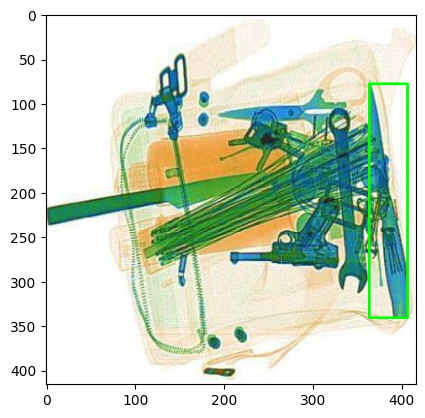

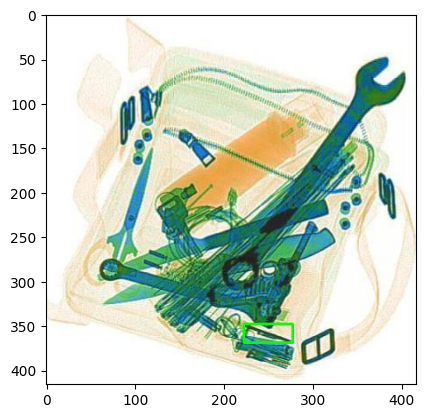

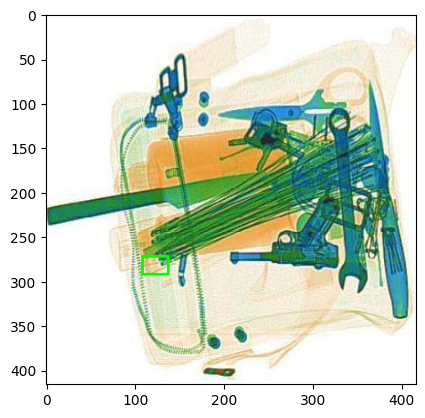

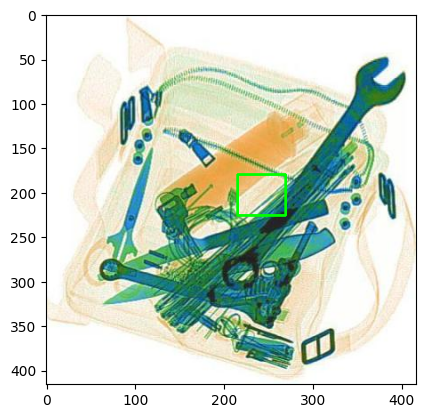

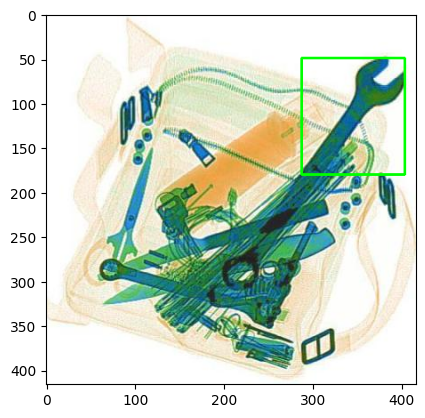

In [6]:
import cv2, random
import matplotlib.pyplot as plt

for r in random.sample(results,5):
    img = cv2.imread(os.path.join(IMAGE_DIR,
          coco.loadImgs(r["image_id"])[0]["file_name"]))
    x,y,w,h = map(int,r["bbox"])
    cv2.rectangle(img,(x,y),(x+w,y+h),(0,255,0),2)
    plt.imshow(img[:,:,::-1]); plt.show()


In [14]:
pip install segment-anything

Note: you may need to restart the kernel to use updated packages.


In [4]:
# =========================================
# SAM + RAXO + DINOv2 DETECTOR
# true RAXO-style detection
# =========================================
import os, glob, json, torch, numpy as np
from PIL import Image
from tqdm import tqdm
from torchvision import transforms
from torchvision.ops import nms
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

# ---------- PATHS ----------
DATA_ROOT = "/Users/user/X-Ray Project/Data"
IMAGE_DIR = os.path.join(DATA_ROOT,"Roboflow_1569/test")
ANN_FILE  = os.path.join(DATA_ROOT,"Roboflow_1569/test/_annotations.coco.json")
INHOUSE   = os.path.join(DATA_ROOT,"RAXO_WEB_InHouse")

SAM_CHECKPOINT = "./sam_vit_h_4b8939.pth"

CLASSES = ["Gun","Scissors","Knife"]

device = "cuda" if torch.cuda.is_available() else "cpu"

# =========================================
# LOAD DINOv2
# =========================================
dino = torch.hub.load('facebookresearch/dinov2','dinov2_vits14').to(device).eval()

transform = transforms.Compose([
    transforms.Resize((252,252)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

def embed(img):
    with torch.no_grad():
        f = dino(transform(img).unsqueeze(0).to(device)).squeeze()
    return f / (f.norm()+1e-6)

# =========================================
# LOAD SAM
# =========================================
sam = sam_model_registry["vit_h"](checkpoint=SAM_CHECKPOINT).to(device)
mask_generator = SamAutomaticMaskGenerator(
    sam,
    points_per_side=32,
    pred_iou_thresh=0.86,
    stability_score_thresh=0.92,
    min_mask_region_area=500
)

# =========================================
# BUILD RAXO PROTOTYPES
# =========================================
coco = COCO(ANN_FILE)
target_ids = coco.getCatIds(catNms=CLASSES)

protos = {}
for cls in CLASSES:
    cid = coco.getCatIds(catNms=[cls])[0]
    feats=[]
    for p in glob.glob(os.path.join(INHOUSE,cls,"*")):
        img = Image.open(p).convert("RGB")
        feats.append(embed(img))
    protos[cid] = torch.stack(feats)
    print(cls,"prototypes:",len(feats))

# =========================================
# SAM PROPOSALS → BBOX
# =========================================
def sam_boxes(img):
    np_img = np.array(img)
    masks = mask_generator.generate(np_img)

    boxes=[]
    for m in masks:
        x,y,w,h = m["bbox"]
        if w*h<500: continue
        boxes.append([x,y,x+w,y+h])
    return boxes

# =========================================
# RAXO DETECTION
# =========================================
def raxo_detect(img):
    boxes=[]
    scores=[]
    labels=[]

    for x1,y1,x2,y2 in sam_boxes(img):
        crop = img.crop((x1,y1,x2,y2))
        f = embed(crop)

        best_cid=None
        best_score=0

        for cid,ps in protos.items():
            sim = torch.nn.functional.cosine_similarity(
                f.unsqueeze(0), ps).max().item()
            if sim>best_score:
                best_score=sim
                best_cid=cid

        if best_score>0.35:
            boxes.append([x1,y1,x2,y2])
            scores.append(best_score)
            labels.append(best_cid)

    if len(boxes)==0:
        return []

    keep=nms(torch.tensor(boxes,dtype=torch.float32),
             torch.tensor(scores),0.5)

    dets=[]
    for i in keep:
        x1,y1,x2,y2=boxes[i]
        dets.append({
            "bbox":[x1,y1,x2-x1,y2-y1],
            "score":scores[i],
            "cid":labels[i]
        })
    return dets

# =========================================
# INFERENCE LOOP
# =========================================
results=[]
for img_id in tqdm(coco.getImgIds(catIds=target_ids)):
    info=coco.loadImgs(img_id)[0]
    path=os.path.join(IMAGE_DIR,info["file_name"])
    img=Image.open(path).convert("RGB")

    dets=raxo_detect(img)
    for d in dets:
        results.append({
            "image_id":img_id,
            "category_id":int(d["cid"]),
            "bbox":[float(v) for v in d["bbox"]],
            "score":float(d["score"])
        })

# =========================================
# COCO EVAL
# =========================================
coco_dt=coco.loadRes(results)
ev=COCOeval(coco,coco_dt,"bbox")
ev.params.catIds=target_ids
ev.evaluate(); ev.accumulate(); ev.summarize()

# =========================================
# METRICS
# =========================================
prec=ev.eval["precision"]
ious=ev.params.iouThrs

idx50=list(ious).index(0.5)
idx75=list(ious).index(0.75)
idx95=list(ious).index(0.95)

mAP,mAP50,mAP75=ev.stats[:3]
AP95=prec[idx95,:,: ,0,-1]
AP95=AP95[AP95>-1].mean()

print("\n=== SAM-RAXO-DINOv2 ===")
print("mAP:",mAP,"mAP50:",mAP50,"mAP75:",mAP75,"mAP95:",AP95)

for cls in CLASSES:
    cid=coco.getCatIds(catNms=[cls])[0]
    idx=target_ids.index(cid)
    ap=prec[:,:,idx,0,-1]; ap=ap[ap>-1].mean()
    ap50=prec[idx50,:,idx,0,-1]; ap50=ap50[ap50>-1].mean()
    ap75=prec[idx75,:,idx,0,-1]; ap75=ap75[ap75>-1].mean()
    ap95=prec[idx95,:,idx,0,-1]; ap95=ap95[ap95>-1].mean()
    print(cls,ap,ap50,ap75,ap95)


Using cache found in /Users/haree/.cache/torch/hub/facebookresearch_dinov2_main


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Gun prototypes: 3
Scissors prototypes: 3
Knife prototypes: 2


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [01:59<00:00, 29.85s/it]

Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.01s).
Accumulating evaluation results...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.011
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.018
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.012
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.050
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.008
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.017
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.017
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=1

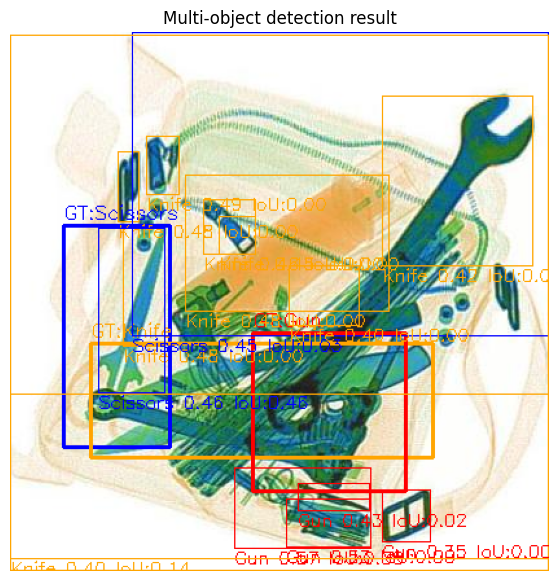

In [5]:
import random, cv2, matplotlib.pyplot as plt

# choose which results to visualize
# results = results_raxo
# results = results_plain
# results = results_gdino

# class colors
class_colors = {
    "Gun": (255,0,0),
    "Scissors": (0,0,255),
    "Knife": (255,165,0)
}

# map image → detections
img_to_dets = {}
for r in results:
    img_to_dets.setdefault(r["image_id"], []).append(r)

# IoU
def iou(a,b):
    xA=max(a[0],b[0])
    yA=max(a[1],b[1])
    xB=min(a[0]+a[2],b[0]+b[2])
    yB=min(a[1]+a[3],b[1]+b[3])
    inter=max(0,xB-xA)*max(0,yB-yA)
    union=a[2]*a[3]+b[2]*b[3]-inter
    return inter/union if union>0 else 0

# pick random image containing any target class
img_id = random.choice(list(img_to_dets.keys()))
info = coco.loadImgs(img_id)[0]
path = os.path.join(IMAGE_DIR, info["file_name"])

img = cv2.imread(path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ---------- DRAW GT ----------
anns = coco.loadAnns(coco.getAnnIds(imgIds=img_id, catIds=target_ids))
for g in anns:
    cls = coco.loadCats(g["category_id"])[0]["name"]
    x,y,w,h = map(int,g["bbox"])
    color = class_colors[cls]
    cv2.rectangle(img,(x,y),(x+w,y+h),color,2)
    cv2.putText(img,f"GT:{cls}",(x,y-5),
                cv2.FONT_HERSHEY_SIMPLEX,0.5,color,1)

# ---------- DRAW PREDICTIONS ----------
for d in img_to_dets[img_id]:
    cls = coco.loadCats(d["category_id"])[0]["name"]
    x,y,w,h = map(int,d["bbox"])
    score = d["score"]
    color = class_colors[cls]

    # best IoU vs GT of same class
    best_iou = 0
    for g in anns:
        if g["category_id"]!=d["category_id"]:
            continue
        best_iou=max(best_iou,iou(d["bbox"],g["bbox"]))

    cv2.rectangle(img,(x,y),(x+w,y+h),color,1)
    cv2.putText(img,f"{cls} {score:.2f} IoU:{best_iou:.2f}",
                (x,y+h+12),cv2.FONT_HERSHEY_SIMPLEX,
                0.45,color,1)

plt.figure(figsize=(7,7))
plt.title("Multi-object detection result")
plt.imshow(img)
plt.axis("off")
plt.show()


In [8]:
# =========================================================
# SAM + RAXO + DINOv2 DETECTOR  (FINAL)
# background-subtracted prototypes + SAM proposals
# =========================================================
import os, glob, json, torch, numpy as np
from PIL import Image
from tqdm import tqdm
from torchvision import transforms
from torchvision.ops import nms
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

# =========================
# PATHS
# =========================
DATA_ROOT = "/Users/user/X-Ray Project/Data"
IMAGE_DIR = os.path.join(DATA_ROOT,"Roboflow_1569/test")
ANN_FILE  = os.path.join(DATA_ROOT,"Roboflow_1569/test/_annotations.coco.json")
INHOUSE   = os.path.join(DATA_ROOT,"RAXO_WEB_InHouse")

SAM_CHECKPOINT = "./sam_vit_h_4b8939.pth"

CLASSES = ["Gun","Scissors","Knife"]
device  = "cuda" if torch.cuda.is_available() else "cpu"

# =========================
# LOAD DINOv2
# =========================
dino = torch.hub.load('facebookresearch/dinov2','dinov2_vits14').to(device).eval()

transform = transforms.Compose([
    transforms.Resize((252,252)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

def embed(img):
    with torch.no_grad():
        f = dino(transform(img).unsqueeze(0).to(device)).squeeze()
    return f / (f.norm()+1e-6)

# =========================
# LOAD SAM
# =========================
sam = sam_model_registry["vit_h"](checkpoint=SAM_CHECKPOINT).to(device)
mask_generator = SamAutomaticMaskGenerator(
    sam,
    points_per_side=32,
    pred_iou_thresh=0.86,
    stability_score_thresh=0.92,
    min_mask_region_area=500
)

# =========================
# LOAD COCO
# =========================
coco = COCO(ANN_FILE)
target_ids = coco.getCatIds(catNms=CLASSES)

# =========================
# BUILD RAXO-v3 PROTOTYPES
# foreground − α·background
# =========================
protos = {}

for cls in CLASSES:
    cid = coco.getCatIds(catNms=[cls])[0]
    feats = []

    for p in glob.glob(os.path.join(INHOUSE,cls,"*")):
        img = Image.open(p).convert("RGB")

        # foreground embedding
        f_fg = embed(img)

        # background crops (corners)
        w,h = img.size
        bg_crops = [
            img.crop((0,0,40,40)),
            img.crop((w-40,0,w,40)),
            img.crop((0,h-40,40,h))
        ]
        f_bg = torch.stack([embed(c) for c in bg_crops]).mean(0)

        # adaptive alpha
        sim = torch.nn.functional.cosine_similarity(
            f_fg.unsqueeze(0), f_bg.unsqueeze(0)).item()
        alpha = max(0.1, min(0.4, sim))

        proto = f_fg - alpha * f_bg
        proto = proto / (proto.norm()+1e-6)

        feats.append(proto)

    protos[cid] = torch.stack(feats)
    print(f"{cls}: {len(feats)} prototypes")

# =========================
# SAM PROPOSALS → BBOX
# =========================
def sam_boxes(img):
    masks = mask_generator.generate(np.array(img))
    boxes = []

    for m in masks:
        x,y,w,h = m["bbox"]
        if w*h < 500:
            continue
        boxes.append([x,y,x+w,y+h])

    return boxes

# =========================
# RAXO DETECTOR
# =========================
def raxo_detect(img):
    boxes=[]
    scores=[]
    labels=[]

    for x1,y1,x2,y2 in sam_boxes(img):
        crop = img.crop((x1,y1,x2,y2))
        f = embed(crop)

        best_cid=None
        best_score=0

        for cid,ps in protos.items():
            sim = torch.nn.functional.cosine_similarity(
                f.unsqueeze(0), ps).max().item()
            if sim > best_score:
                best_score = sim
                best_cid = cid

        if best_score > 0.35:
            boxes.append([x1,y1,x2,y2])
            scores.append(best_score)
            labels.append(best_cid)

    if len(boxes)==0:
        return []

    keep = nms(torch.tensor(boxes,dtype=torch.float32),
               torch.tensor(scores),0.5)

    dets=[]
    for i in keep:
        x1,y1,x2,y2 = boxes[i]
        dets.append({
            "bbox":[x1,y1,x2-x1,y2-y1],
            "score":scores[i],
            "cid":labels[i]
        })

    return dets

# =========================
# INFERENCE LOOP
# =========================
results = []

for img_id in tqdm(coco.getImgIds(catIds=target_ids)):
    info = coco.loadImgs(img_id)[0]
    path = os.path.join(IMAGE_DIR,info["file_name"])
    img  = Image.open(path).convert("RGB")

    dets = raxo_detect(img)

    for d in dets:
        results.append({
            "image_id":img_id,
            "category_id":int(d["cid"]),
            "bbox":[float(v) for v in d["bbox"]],
            "score":float(d["score"])
        })

# =========================
# COCO EVAL
# =========================
coco_dt = coco.loadRes(results)
ev = COCOeval(coco,coco_dt,"bbox")
ev.params.catIds = target_ids
ev.evaluate(); ev.accumulate(); ev.summarize()

# =========================
# METRICS
# =========================
prec = ev.eval["precision"]
ious = ev.params.iouThrs

idx50 = list(ious).index(0.5)
idx75 = list(ious).index(0.75)
idx95 = list(ious).index(0.95)

mAP,mAP50,mAP75 = ev.stats[:3]
AP95 = prec[idx95,:,: ,0,-1]
AP95 = AP95[AP95>-1].mean()

print("\n===== SAM-RAXO-DINOv2 =====")
print(f"mAP   : {mAP:.4f}")
print(f"mAP50 : {mAP50:.4f}")
print(f"mAP75 : {mAP75:.4f}")
print(f"mAP95 : {AP95:.4f}")

print("\n===== PER CLASS =====")
for cls in CLASSES:
    cid = coco.getCatIds(catNms=[cls])[0]
    idx = target_ids.index(cid)

    ap = prec[:,:,idx,0,-1]
    ap = ap[ap>-1].mean()

    ap50 = prec[idx50,:,idx,0,-1]
    ap50 = ap50[ap50>-1].mean()

    ap75 = prec[idx75,:,idx,0,-1]
    ap75 = ap75[ap75>-1].mean()

    ap95 = prec[idx95,:,idx,0,-1]
    ap95 = ap95[ap95>-1].mean()

    print(f"{cls:8s} | AP:{ap:.4f}  AP50:{ap50:.4f}  AP75:{ap75:.4f}  AP95:{ap95:.4f}")


Using cache found in /Users/haree/.cache/torch/hub/facebookresearch_dinov2_main


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Gun: 1 prototypes
Scissors: 2 prototypes
Knife: 1 prototypes


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [02:01<00:00, 30.48s/it]

Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.01s).
Accumulating evaluation results...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.009
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.016
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.010
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.049
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.008
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.011
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.011
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=1

In [2]:
import os
import json
from collections import Counter, defaultdict

# =========================
# PATHS
# =========================
root = "/Users/user/X-Ray Project/Data/DET-Compass"
img_dir = os.path.join(root, "images")
ann_path = os.path.join(root, "annotations.json")

# =========================
# LOAD ANNOTATIONS
# =========================
with open(ann_path, "r") as f:
    annotations = json.load(f)

print("Total annotation entries:", len(annotations))

Total annotation entries: 1573
